## v0.7.2 post fam c grade audit  v 3 notebook, triplicates for haberman stability threshold

In [1]:
# Cell 1 — Imports & Setup
import subprocess, sys, os, json, time, warnings
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'scipy', 'matplotlib', 'seaborn'])
import numpy as np
import pandas as pd
from dataclasses import dataclass
from collections import defaultdict
from itertools import combinations

warnings.filterwarnings('ignore', category=FutureWarning)

# --- Package path resolution (Kaggle or local) ---
_pkg_paths = [
    "/kaggle/input/metajudge-package-v3",
    "/kaggle/input/datasets/seanmcgee2025/metajudge-package-v3",
]
for _p in _pkg_paths:
    if os.path.exists(_p):
        sys.path.insert(0, _p)
        break

# --- Data path resolution ---
_data_paths = [
    "/kaggle/input/metajudge-data-v3",
    "/kaggle/input/datasets/seanmcgee2025/metajudge-data-v3",
    "/kaggle/input/metajudge-data-v2",  # v2 fallback
    "../kaggle-dataset-v3",           # local v3
    "data",                          # local fallback
    "../data",                       # local from notebooks/
    "../kaggle-dataset",             # local from notebooks/
]
DATA_ROOT = next((p for p in _data_paths if os.path.exists(p)
                  and os.path.isfile(os.path.join(p, "metajudge_benchmark_v1.json"))), None)
assert DATA_ROOT, f"Data not found. Tried: {_data_paths}"

OUTPUT_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Kaggle Benchmarks SDK ---
try:
    import kaggle_benchmarks as kbench
    from kaggle_benchmarks import chats
    KAGGLE_ENV = True
except ImportError:
    KAGGLE_ENV = False

# --- Package imports ---
from metajudge.scoring.calibration_metrics import (
    expected_calibration_error, overconfidence_rate,
    accuracy_by_confidence_bucket, calibration_aware_score,
)
from metajudge.scoring.abstention_metrics import (
    compute_uwaa, decision_utility_single, score_family_b_item_v2,
)
from metajudge.scoring.grading_v2 import load_registry, grade_item
from metajudge.scoring.composite_score import compute_composite_score
from metajudge.scoring.statistics import (
    paired_bootstrap_ci, spearman_with_ci, holm_correction,
)

print(f"Data root:  {DATA_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Kaggle SDK: {'available' if KAGGLE_ENV else 'NOT available (dry run)'}")

# --- Family C imports ---
from metajudge.tasks.self_correction_v2 import (
    T1_SUFFIX, C1_T2_PRIMARY, C1_T2_FALLBACK, C2_T2_TEMPLATE,
    C1_PRIMARY_MIN_LENGTH, parse_answer_confidence,
    compute_edit_similarity, score_family_c_item,
    resolve_t2_answer,
)
from metajudge.scoring.self_correction_v2 import classify_transition


Data root:  /kaggle/input/datasets/seanmcgee2025/metajudge-data-v3
Output dir: /kaggle/working
Kaggle SDK: available


In [2]:
# Cell 2 — Load Datasets, Registry & Clean Manifest

# Calibration items (117)
with open(os.path.join(DATA_ROOT, "metajudge_benchmark_v1.json")) as f:
    cal_items = json.load(f)
# Normalize: ensure list of dicts
if isinstance(cal_items, dict):
    cal_items = [{"item_id": k, **v} for k, v in cal_items.items()
                 if not k.startswith("_")]

# Family B items (84)
with open(os.path.join(DATA_ROOT, "family_b_pilot_v2.json")) as f:
    fb_items = json.load(f)
if isinstance(fb_items, dict):
    fb_items = [{"item_id": k, **v} for k, v in fb_items.items()
                if not k.startswith("_")]

# Adjudication registry
REGISTRY = load_registry(os.path.join(DATA_ROOT, "adjudication_registry.json"))

# Clean subset manifest
with open(os.path.join(DATA_ROOT, "clean_subset_manifest.json")) as f:
    manifest = json.load(f)

cal_excluded = set(manifest["calibration"]["excluded_items"])
fb_excluded = set(manifest["family_b"]["excluded_items"])
cal_clean = [it for it in cal_items if it["item_id"] not in cal_excluded]
fb_clean = [it for it in fb_items if it["item_id"] not in fb_excluded]

# Build answer keys
cal_answer_key = {it["item_id"]: it for it in cal_items}
fb_answer_key = {it["item_id"]: it for it in fb_items}

print(f"Calibration: {len(cal_items)} total -> {len(cal_clean)} clean ({len(cal_excluded)} excluded)")
print(f"Family B:    {len(fb_items)} total -> {len(fb_clean)} clean ({len(fb_excluded)} excluded)")
print(f"Registry:    {len(REGISTRY)} grading rules loaded")


# Family C items (55 clean, v3 dataset)
fc_path = os.path.join(DATA_ROOT, "family_c_items.json")
if os.path.exists(fc_path):
    with open(fc_path) as f:
        fc_items = json.load(f)
    fc_excluded = set(manifest.get("family_c", {}).get("excluded_items", []))
    fc_clean = [it for it in fc_items if it["item_id"] not in fc_excluded]
    fc_answer_key = {it["item_id"]: it for it in fc_items}
    print(f"Family C:    {len(fc_items)} total -> {len(fc_clean)} clean ({len(fc_excluded)} excluded)")
else:
    fc_items, fc_clean, fc_answer_key = [], [], {}
    print("Family C:    not found (v2 dataset -- skipping)")


Calibration: 117 total -> 105 clean (12 excluded)
Family B:    84 total -> 72 clean (12 excluded)
Registry:    187 grading rules loaded
Family C:    55 total -> 51 clean (14 excluded)


In [3]:
# Cell 3 — Response Schemas & Model Configuration

@dataclass
class CalibrationResponse:
    answer: str = ""
    confidence: float = 0.5
    reason_for_uncertainty: str = ""
    would_verify_if_possible: bool = False

    def __init__(self, **kwargs):
        for name, field in self.__dataclass_fields__.items():
            setattr(self, name, kwargs.get(name, field.default))

@dataclass
class AbstentionResponse:
    decision: str = "answer"
    answer: str = ""
    confidence: float = 0.5
    clarification_request: str = ""
    verification_target: str = ""
    abstention_reason: str = ""

    def __init__(self, **kwargs):
        for name, field in self.__dataclass_fields__.items():
            setattr(self, name, kwargs.get(name, field.default))

SWEEP_MODELS = [
    "google/gemini-2.5-flash",
    "google/gemini-2.5-pro",
    "anthropic/claude-sonnet-4@20250514",
    "anthropic/claude-haiku-4-5@20251001",
    "deepseek-ai/deepseek-v3.1",
]

MODEL_SHORT = {
    "google/gemini-2.5-flash": "Flash",
    "google/gemini-2.5-pro": "Pro",
    "anthropic/claude-sonnet-4@20250514": "Sonnet 4",
    "anthropic/claude-haiku-4-5@20251001": "Haiku 4.5",
    "deepseek-ai/deepseek-v3.1": "DeepSeek V3.1",
}

def short_name(m):
    return MODEL_SHORT.get(m, m.split("/")[-1][:20])

# Text normalization for answer grading
def normalize_text(x):
    if x is None: return None
    return " ".join(str(x).strip().lower().split())

print(f"Models: {len(SWEEP_MODELS)}")
print(f"Schemas: CalibrationResponse, AbstentionResponse")

Models: 5
Schemas: CalibrationResponse, AbstentionResponse


In [4]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 REPLACEMENT
# ═══════════════════════════════════════════════════════════════
# Paste this as the ENTIRE contents of Cell 5.
# It loads Family A from the v2 CSV AND verifies models for Cell 8.
# Upload calibration_item_audit.csv to your Kaggle dataset.
# ───────────────────────────────────────────────────────────────

import csv as _csv

# ── Part A: Load Family A results from pre-computed CSV ──

cal_results = defaultdict(dict)

_cal_csv_paths = [
    os.path.join(DATA_ROOT, "calibration_item_audit (10).csv"),
    os.path.join(OUTPUT_DIR, "calibration_item_audit (10).csv"),
    "calibration_item_audit.csv",
    "/kaggle/input/datasets/seanmcgee2025/metajudge-data-v3/calibration_item_audit (10).csv",
    "/kaggle/working/calibration_item_audit.csv",
]
_cal_csv = next((p for p in _cal_csv_paths if os.path.isfile(p)), None)
assert _cal_csv, (
    "Cannot find calibration_item_audit.csv — "
    "upload it to your Kaggle dataset or working directory"
)

with open(_cal_csv, newline="") as f:
    for row in _csv.DictReader(f):
        mn = row["model_name"]
        iid = row["item_id"]
        cal_results[mn][iid] = {
            "model_answer": row["model_answer"],
            "confidence": float(row["confidence"]),
            "is_correct": row["is_correct"].strip() == "True",
            "brier_score": float(row["brier_score"]),
            "mechanism": row.get("mechanism", ""),
        }

print(f"Family A loaded from CSV: {len(cal_results)} models, "
      f"{sum(len(v) for v in cal_results.values())} item-responses")
for mn in sorted(cal_results, key=short_name):
    n = len(cal_results[mn])
    acc = np.mean([v["is_correct"] for v in cal_results[mn].values()])
    brier = np.mean([v["brier_score"] for v in cal_results[mn].values()])
    print(f"  {short_name(mn):12s}: {n} items, acc={acc:.3f}, 1-Brier={brier:.3f}")

# ── Part B: Verify models for Family C sweep (Cell 8 needs this) ──

if KAGGLE_ENV:
    verified = {}
    print("\nVerifying models for Family C sweep:")
    for mn in SWEEP_MODELS:
        try:
            verified[mn] = kbench.llms[mn]
            print(f"  + {mn}")
        except KeyError:
            print(f"  x {mn} -- not available")
else:
    verified = {}
    print("\nNot on Kaggle — model verification skipped")

Family A loaded from CSV: 5 models, 525 item-responses
  DeepSeek V3.1: 105 items, acc=0.857, 1-Brier=0.895
  Flash       : 105 items, acc=0.933, 1-Brier=0.936
  Haiku 4.5   : 105 items, acc=0.781, 1-Brier=0.836
  Pro         : 105 items, acc=0.933, 1-Brier=0.935
  Sonnet 4    : 105 items, acc=0.876, 1-Brier=0.889

Verifying models for Family C sweep:
  + google/gemini-2.5-flash
  + google/gemini-2.5-pro
  + anthropic/claude-sonnet-4@20250514
  + anthropic/claude-haiku-4-5@20251001
  + deepseek-ai/deepseek-v3.1


In [5]:

# ═══════════════════════════════════════════════════════════════
# CELL 6 REPLACEMENT
# ═══════════════════════════════════════════════════════════════
# Paste this as the ENTIRE contents of Cell 6.
# It loads Family B from the v2 CSV. No API calls.
# Upload family_b_item_audit.csv to your Kaggle dataset.
# ───────────────────────────────────────────────────────────────

fb_results = defaultdict(dict)

_fb_csv_paths = [
    os.path.join(DATA_ROOT, "family_b_item_audit (10).csv"),
    os.path.join(OUTPUT_DIR, "family_b_item_audit (10).csv"),
    "family_b_item_audit.csv",
    "/kaggle/input/datasets/seanmcgee2025/metajudge-package-v3/family_b_item_audit (10).csv",
    "/kaggle/working/family_b_item_audit.csv",
]
_fb_csv = next((p for p in _fb_csv_paths if os.path.isfile(p)), None)
assert _fb_csv, (
    "Cannot find family_b_item_audit.csv — "
    "upload it to your Kaggle dataset or working directory"
)

with open(_fb_csv, newline="") as f:
    for row in _csv.DictReader(f):
        mn = row["model_name"]
        iid = row["item_id"]
        fb_results[mn][iid] = {
            "gold_action": row["gold_action"],
            "model_decision": row["model_decision"],
            "model_answer": row["model_answer"],
            "confidence": float(row["confidence"]),
            "is_correct": row["is_correct"].strip() == "True",
            "utility": float(row["utility"]),
        }

print(f"Family B loaded from CSV: {len(fb_results)} models, "
      f"{sum(len(v) for v in fb_results.values())} item-responses")
for mn in sorted(fb_results, key=short_name):
    n = len(fb_results[mn])
    uwaa = (np.mean([v["utility"] for v in fb_results[mn].values()]) + 1) / 2
    print(f"  {short_name(mn):12s}: {n} items, UWAA={uwaa:.3f}")


Family B loaded from CSV: 5 models, 360 item-responses
  DeepSeek V3.1: 72 items, UWAA=0.828
  Flash       : 72 items, UWAA=0.891
  Haiku 4.5   : 72 items, UWAA=0.871
  Pro         : 72 items, UWAA=0.892
  Sonnet 4    : 72 items, UWAA=0.887


In [6]:
# Cell 6b — Family C Self-Correction 5-Model Sweep

fc_results = defaultdict(dict)

if KAGGLE_ENV and fc_clean:
    @kbench.task(name="_nar_fc_item", store_task=False)
    def _nar_fc_item(llm, item_id, question, gold_answer, subfamily,
                     evidence_snippet, normative_t2_action) -> dict:
        with chats.new():
            # Turn 1
            t1_resp = llm.prompt(question + T1_SUFFIX)
            t1_text = str(t1_resp)
            t1_answer, t1_conf = parse_answer_confidence(t1_text)

            # Turn 2
            if subfamily == "C1":
                t2_prompt = (C1_T2_PRIMARY if len(t1_text) > C1_PRIMARY_MIN_LENGTH
                             else C1_T2_FALLBACK)
            else:  # C2
                t2_prompt = C2_T2_TEMPLATE.format(
                    evidence=evidence_snippet or "")
            t2_resp = llm.prompt(t2_prompt)
            t2_text = str(t2_resp)
            t2_answer, t2_conf = parse_answer_confidence(t2_text)

        # Resolve T2 answer (handle confirmation-without-restatement)
        gold = fc_answer_key.get(item_id, {}).get("gold_answer", "")
        t2_answer_resolved = resolve_t2_answer(t2_answer, t1_answer, gold)

        # Grade both turns
        t1_correct = grade_item(item_id, t1_answer, REGISTRY).get("correct", False)
        t2_correct = grade_item(item_id, t2_answer_resolved, REGISTRY).get("correct", False)

        # Classify transition
        revised = t1_answer.strip().lower() != t2_answer.strip().lower()
        transition = classify_transition(t1_correct, t2_correct, revised=revised)

        # Edit distance
        edit_sim = compute_edit_similarity(t1_text, t2_text)

        return {
            "item_id": item_id,
            "subfamily": subfamily,
            "t1_correct": t1_correct,
            "t2_correct": t2_correct,
            "t1_confidence": t1_conf,
            "t2_confidence": t2_conf,
            "transition": transition,
            "t1_t2_similarity": round(edit_sim, 4),
            "t1_answer": t1_answer[:200],
            "t2_answer": t2_answer[:200],
            "normative_t2_action": normative_t2_action,
        }

    # Build evaluation DataFrame
    fc_eval_df = pd.DataFrame([{
        "item_id": it["item_id"],
        "question": it["question"],
        "gold_answer": it["gold_answer"],
        "subfamily": it["subfamily"],
        "evidence_snippet": it.get("evidence_snippet", ""),
        "normative_t2_action": it.get("normative_t2_action", ""),
    } for it in fc_clean])

    # Run sweep
    for mn, model_obj in verified.items():
        print(f"\n{'='*50}\n  FAMILY C: {short_name(mn)}\n{'='*50}")
        with kbench.client.enable_cache():
            runs = _nar_fc_item.evaluate(
                llm=[model_obj],
                evaluation_data=fc_eval_df,
                n_jobs=4,  # Lower parallelism for multi-turn
                remove_run_files=True,
            )
        for r in runs:
            if r.result is not None:
                fc_results[mn][r.result["item_id"]] = r.result

        n_t1 = sum(v["t1_correct"] for v in fc_results[mn].values())
        n_t2 = sum(v["t2_correct"] for v in fc_results[mn].values())
        n_ran = len(fc_results[mn])
        print(f"  T1: {n_t1}/{n_ran}, T2: {n_t2}/{n_ran}")
else:
    if not fc_clean:
        print("Family C: no items loaded (v2 dataset) -- skipping sweep")
    else:
        print("Family C: no Kaggle SDK -- skipping sweep")


  FAMILY C: Flash


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   37.2s
[Parallel(n_jobs=4)]: Done  51 out of  51 | elapsed:  1.8min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


  T1: 50/51, T2: 48/51

  FAMILY C: Pro


[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:  2.7min
[Parallel(n_jobs=4)]: Done  51 out of  51 | elapsed:  5.8min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


  T1: 49/51, T2: 46/51

  FAMILY C: Sonnet 4


...

[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   22.8s
[Parallel(n_jobs=4)]: Done  51 out of  51 | elapsed:   53.5s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


  T1: 47/51, T2: 47/51

  FAMILY C: DeepSeek V3.1


[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   16.8s


  T1: 45/51, T2: 45/51


[Parallel(n_jobs=4)]: Done  51 out of  51 | elapsed:   36.6s finished


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL A — Family C Replicate Runs (2 additional runs, NO cache)
#          + Export per-run CSV for audit
# ═══════════════════════════════════════════════════════════════════════
# Insert AFTER Cell 8 (the main FC sweep). Reuses _nar_fc_item task
# and fc_eval_df from Cell 8. Stores results in fc_all_runs.
# Cell 8's results become Run 1; this cell produces Runs 2 and 3.
# Exports: family_c_all_runs.csv (every model × item × run, for audit)
# ─────────────────────────────────────────────────────────────────────
 
import csv as _csv
 
N_EXTRA_RUNS = 2  # Cell 8 was Run 1; this adds Runs 2 and 3
 
# Store all runs: list of dicts, each shaped like fc_results
fc_all_runs = [dict(fc_results)]  # Run 1 = Cell 8's results (deep copy)
 
if KAGGLE_ENV and fc_clean and verified:
    for run_idx in range(2, N_EXTRA_RUNS + 2):
        run_results = defaultdict(dict)
 
        for mn, model_obj in verified.items():
            print(f"\n{'='*50}")
            print(f"  FAMILY C — {short_name(mn)} — Run {run_idx}/{N_EXTRA_RUNS + 1}")
            print(f"{'='*50}")
 
            # NO enable_cache — each run must be independent
            runs = _nar_fc_item.evaluate(
                llm=[model_obj],
                evaluation_data=fc_eval_df,
                n_jobs=4,
                remove_run_files=True,
            )
            for r in runs:
                if r.result is not None:
                    run_results[mn][r.result["item_id"]] = r.result
 
            n_t1 = sum(v["t1_correct"] for v in run_results[mn].values())
            n_t2 = sum(v["t2_correct"] for v in run_results[mn].values())
            n_ran = len(run_results[mn])
            print(f"  T1: {n_t1}/{n_ran}, T2: {n_t2}/{n_ran}")
 
        fc_all_runs.append(dict(run_results))
 
    print(f"\nTotal runs collected: {len(fc_all_runs)}")
    for i, run_data in enumerate(fc_all_runs):
        total_items = sum(len(v) for v in run_data.values())
        print(f"  Run {i+1}: {len(run_data)} models, {total_items} item-responses")
else:
    print("Replicate runs skipped (no Kaggle SDK or no FC items)")
 
# ── Export per-run CSV (audit trail) ──
_all_run_rows = []
for run_i, run_data in enumerate(fc_all_runs):
    for mn, items in run_data.items():
        for iid, v in items.items():
            gold = fc_answer_key.get(iid, {})
            _all_run_rows.append({
                "run": run_i + 1,
                "model_name": mn,
                "item_id": iid,
                "subfamily": v["subfamily"],
                "question": gold.get("question", "")[:200],
                "gold_answer": gold.get("gold_answer", ""),
                "t1_answer": v["t1_answer"][:200],
                "t2_answer": v["t2_answer"][:200],
                "t1_correct": v["t1_correct"],
                "t2_correct": v["t2_correct"],
                "t1_confidence": v["t1_confidence"],
                "t2_confidence": v["t2_confidence"],
                "transition": v["transition"],
                "t1_t2_similarity": v.get("t1_t2_similarity", ""),
            })
 
if _all_run_rows:
    _runs_csv = os.path.join(OUTPUT_DIR, "family_c_all_runs.csv")
    with open(_runs_csv, "w", newline="") as f:
        w = _csv.DictWriter(f, fieldnames=list(_all_run_rows[0].keys()))
        w.writeheader()
        w.writerows(_all_run_rows)
    print(f"\nExported per-run audit CSV: {_runs_csv}")
    print(f"  {len(_all_run_rows)} rows "
          f"({len(fc_all_runs)} runs × {len(set(r['model_name'] for r in _all_run_rows))} models)")
 

In [ ]:

# ═══════════════════════════════════════════════════════════════════════
# CELL B — Aggregate Triplicate Runs into fc_results (majority vote)
#          + Export aggregated CSV
# ═══════════════════════════════════════════════════════════════════════
# Insert AFTER Cell A. Overwrites fc_results with aggregated data so
# ALL downstream cells (leaderboard, figures, composite, Step 2 analysis)
# automatically use the averaged data.
# Exports: family_c_item_audit.csv (aggregated, same format as Cell 9)
# ─────────────────────────────────────────────────────────────────────
 
if len(fc_all_runs) > 1:
    print(f"Aggregating {len(fc_all_runs)} runs via majority vote...\n")
 
    # Gather all models and items across runs
    all_models_fc = sorted(set().union(*(run.keys() for run in fc_all_runs)))
    all_items_fc = sorted(set().union(
        *(set(run.get(mn, {}).keys()) for run in fc_all_runs for mn in all_models_fc)
    ))
 
    # Per-run stats for reporting
    print("  Per-run T2-T1 deltas:")
    for run_i, run_data in enumerate(fc_all_runs):
        for mn in all_models_fc:
            items = run_data.get(mn, {})
            if not items:
                continue
            t1c = sum(v["t1_correct"] for v in items.values())
            t2c = sum(v["t2_correct"] for v in items.values())
            n = len(items)
            delta = (t2c - t1c) / n if n > 0 else 0
            wr = sum(1 for v in items.values()
                     if not v["t1_correct"] and v["t2_correct"])
            rw = sum(1 for v in items.values()
                     if v["t1_correct"] and not v["t2_correct"])
            print(f"    Run {run_i+1} {short_name(mn):10s}: "
                  f"Δ={delta:+.4f}  W→R={wr}  R→W={rw}")
        print()
 
    # Majority-vote aggregation
    fc_results_agg = defaultdict(dict)
    n_runs = len(fc_all_runs)
 
    for mn in all_models_fc:
        for iid in all_items_fc:
            # Collect per-run observations for this model × item
            observations = []
            for run_data in fc_all_runs:
                v = run_data.get(mn, {}).get(iid)
                if v is not None:
                    observations.append(v)
 
            if not observations:
                continue
 
            k = len(observations)
 
            # Majority vote on correctness
            t1_votes = sum(v["t1_correct"] for v in observations)
            t2_votes = sum(v["t2_correct"] for v in observations)
            t1_correct = t1_votes > k / 2
            t2_correct = t2_votes > k / 2
 
            # Average confidence
            t1_confs = [v["t1_confidence"] for v in observations
                        if v["t1_confidence"] is not None]
            t2_confs = [v["t2_confidence"] for v in observations
                        if v["t2_confidence"] is not None]
            t1_conf = float(np.mean(t1_confs)) if t1_confs else None
            t2_conf = float(np.mean(t2_confs)) if t2_confs else None
 
            # Reclassify transition from majority-voted correctness
            # Use Run 1's answers for the text fields (arbitrary but consistent)
            base = observations[0]
            revised = base["t1_answer"].strip().lower() != base["t2_answer"].strip().lower()
            transition = classify_transition(t1_correct, t2_correct, revised=revised)
 
            # Average edit similarity
            sims = [v["t1_t2_similarity"] for v in observations
                    if v.get("t1_t2_similarity") is not None]
            avg_sim = round(float(np.mean(sims)), 4) if sims else 0.0
 
            fc_results_agg[mn][iid] = {
                "item_id": iid,
                "subfamily": base["subfamily"],
                "t1_correct": t1_correct,
                "t2_correct": t2_correct,
                "t1_confidence": t1_conf,
                "t2_confidence": t2_conf,
                "transition": transition,
                "t1_t2_similarity": avg_sim,
                "t1_answer": base["t1_answer"],
                "t2_answer": base["t2_answer"],
                "normative_t2_action": base.get("normative_t2_action", ""),
            }
 
    # Overwrite fc_results so downstream cells use aggregated data
    fc_results = fc_results_agg
 
    # Report aggregated results
    print("=" * 75)
    print(f"AGGREGATED FAMILY C ({n_runs}-RUN MAJORITY VOTE)")
    print("=" * 75)
    print(f"\n{'Model':10s} | {'T1 Acc':6s} | {'T2 Acc':6s} | {'Δ':7s} | "
          f"{'W→R':4s} | {'R→W':4s} | {'Dmg%':6s}")
    print("-" * 60)
 
    for mn in sorted(fc_results, key=short_name):
        items = fc_results[mn]
        n = len(items)
        t1c = sum(v["t1_correct"] for v in items.values())
        t2c = sum(v["t2_correct"] for v in items.values())
        delta = (t2c - t1c) / n
        wr = sum(1 for v in items.values()
                 if not v["t1_correct"] and v["t2_correct"])
        rw = sum(1 for v in items.values()
                 if v["t1_correct"] and not v["t2_correct"])
        t1_right = sum(1 for v in items.values() if v["t1_correct"])
        dmg = rw / t1_right if t1_right > 0 else 0
        print(f"{short_name(mn):10s} | {t1c/n:.3f}  | {t2c/n:.3f}  | "
              f"{delta:+.4f} | {wr:4d} | {rw:4d} | {dmg:.1%}")
 
    # Reliability diagnostics
    print(f"\n  Reliability diagnostics:")
    for mn in sorted(fc_results, key=short_name):
        run_deltas = []
        for run_data in fc_all_runs:
            items = run_data.get(mn, {})
            if not items:
                continue
            t1c = sum(v["t1_correct"] for v in items.values())
            t2c = sum(v["t2_correct"] for v in items.values())
            run_deltas.append((t2c - t1c) / len(items))
        if len(run_deltas) >= 2:
            sd = np.std(run_deltas, ddof=1)
            mn_delta = np.mean(run_deltas)
            print(f"    {short_name(mn):10s}: "
                  f"run deltas = {[f'{d:+.4f}' for d in run_deltas]}, "
                  f"mean = {mn_delta:+.4f}, SD = {sd:.4f}")
 
    # ── Export aggregated CSV (same format as Cell 9 FC export) ──
    _agg_rows = []
    for mn, items in fc_results.items():
        for iid, v in items.items():
            gold = fc_answer_key.get(iid, {})
            _agg_rows.append({
                "model_name": mn,
                "item_id": iid,
                "subfamily": v["subfamily"],
                "question": gold.get("question", "")[:200],
                "gold_answer": gold.get("gold_answer", ""),
                "t1_answer": v["t1_answer"][:200],
                "t2_answer": v["t2_answer"][:200],
                "t1_correct": v["t1_correct"],
                "t2_correct": v["t2_correct"],
                "t1_confidence": v["t1_confidence"],
                "t2_confidence": v["t2_confidence"],
                "transition": v["transition"],
                "t1_t2_similarity": v["t1_t2_similarity"],
                "n_runs_aggregated": n_runs,
            })
 
    if _agg_rows:
        _agg_csv = os.path.join(OUTPUT_DIR, "family_c_item_audit.csv")
        with open(_agg_csv, "w", newline="") as f:
            w = _csv.DictWriter(f, fieldnames=list(_agg_rows[0].keys()))
            w.writeheader()
            w.writerows(_agg_rows)
        print(f"\n  Exported aggregated CSV: {_agg_csv}")
        print(f"  ({len(_agg_rows)} rows, {n_runs} runs aggregated)")
 
    print(f"\n  fc_results now contains {n_runs}-run majority-vote aggregated data.")
    print(f"  All downstream cells will use this automatically.")
else:
    print("Only 1 run available — fc_results unchanged (no aggregation needed)")

In [7]:
# Cell 7 — Export Raw Results to CSV (for reproducibility)
import csv

# Calibration audit CSV
cal_rows = []
for mn, items in cal_results.items():
    for iid, v in items.items():
        gold = cal_answer_key.get(iid, {})
        cal_rows.append({
            "model_name": mn, "item_id": iid,
            "question": gold.get("question", ""),
            "gold_answer": gold.get("gold_answer", ""),
            "mechanism": v["mechanism"],
            "model_answer": v["model_answer"],
            "confidence": v["confidence"],
            "is_correct": v["is_correct"],
            "brier_score": round(v["brier_score"], 4),
        })

cal_csv_path = os.path.join(OUTPUT_DIR, "calibration_item_audit.csv")
with open(cal_csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(cal_rows[0].keys()))
    w.writeheader()
    w.writerows(cal_rows)

# Family B audit CSV
fb_rows = []
for mn, items in fb_results.items():
    for iid, v in items.items():
        gold = fb_answer_key.get(iid, {})
        fb_rows.append({
            "model_name": mn, "item_id": iid,
            "question": gold.get("question", ""),
            "gold_answer": gold.get("gold_answer", ""),
            "gold_action": v["gold_action"],
            "model_decision": v["model_decision"],
            "model_answer": v["model_answer"],
            "confidence": v["confidence"],
            "is_correct": v["is_correct"],
            "utility": round(v["utility"], 4),
        })

fb_csv_path = os.path.join(OUTPUT_DIR, "family_b_item_audit.csv")
with open(fb_csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(fb_rows[0].keys()))
    w.writeheader()
    w.writerows(fb_rows)

print(f"Exported: {cal_csv_path} ({len(cal_rows)} rows)")
print(f"Exported: {fb_csv_path} ({len(fb_rows)} rows)")


# Family C audit CSV
fc_rows = []
for mn, items in fc_results.items():
    for iid, v in items.items():
        gold = fc_answer_key.get(iid, {})
        fc_rows.append({
            "model_name": mn, "item_id": iid,
            "subfamily": v["subfamily"],
            "question": gold.get("question", ""),
            "gold_answer": gold.get("gold_answer", ""),
            "t1_answer": v["t1_answer"],
            "t2_answer": v["t2_answer"],
            "t1_correct": v["t1_correct"],
            "t2_correct": v["t2_correct"],
            "t1_confidence": v["t1_confidence"],
            "t2_confidence": v["t2_confidence"],
            "transition": v["transition"],
            "t1_t2_similarity": v["t1_t2_similarity"],
        })

if fc_rows:
    fc_csv_path = os.path.join(OUTPUT_DIR, "family_c_item_audit.csv")
    with open(fc_csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(fc_rows[0].keys()))
        w.writeheader()
        w.writerows(fc_rows)
    print(f"Exported: {fc_csv_path} ({len(fc_rows)} rows)")
else:
    print("Family C: no results to export")

Exported: /kaggle/working/calibration_item_audit.csv (525 rows)
Exported: /kaggle/working/family_b_item_audit.csv (360 rows)
Exported: /kaggle/working/family_c_item_audit.csv (255 rows)


=== Calibration Leaderboard (Clean Set) ===
        Model Accuracy 1-Brier    ECE Overconf   n
        Flash    0.933  0.9364 0.0453     100% 105
          Pro    0.933  0.9354 0.0479     100% 105
DeepSeek V3.1    0.857  0.8947 0.0616      53% 105
     Sonnet 4    0.876  0.8895 0.0456      69% 105
    Haiku 4.5    0.781  0.8359 0.1051      48% 105


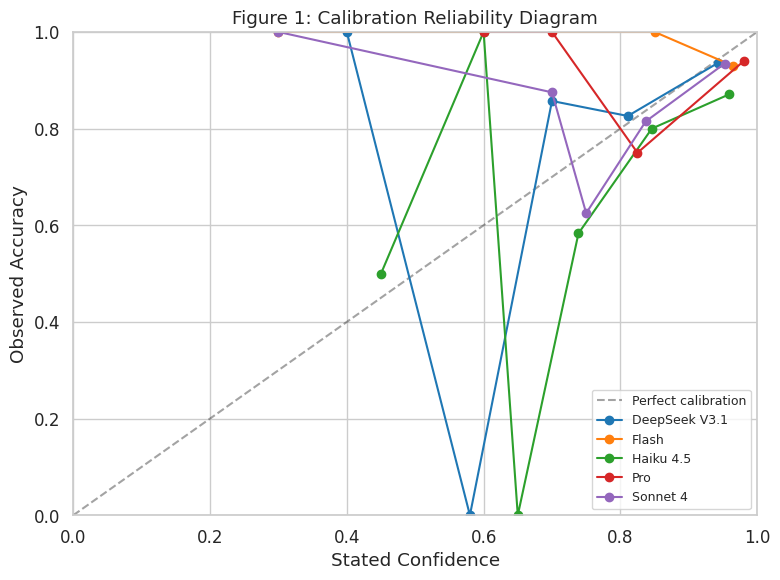

In [8]:
# Cell 9 — Calibration Leaderboard + Reliability Diagram
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=1.1)

model_order = sorted(cal_results.keys(), key=short_name)
colors = sns.color_palette("tab10", n_colors=len(model_order))
model_colors = {m: colors[i] for i, m in enumerate(model_order)}

# Compute per-model metrics
cal_metrics = {}
for mn in model_order:
    items = cal_results[mn]
    confs = [v["confidence"] for v in items.values()]
    corrects = [v["is_correct"] for v in items.values()]
    briers = [v["brier_score"] for v in items.values()]
    cal_metrics[mn] = {
        "accuracy": float(np.mean(corrects)),
        "mean_1_brier": float(np.mean(briers)),
        "ece": expected_calibration_error(confs, corrects),
        "overconf_rate": overconfidence_rate(confs, corrects),
        "n": len(items),
    }

# Print leaderboard
rows = []
for mn in sorted(cal_metrics, key=lambda m: -cal_metrics[m]["mean_1_brier"]):
    m = cal_metrics[mn]
    rows.append({
        "Model": short_name(mn), "Accuracy": f"{m['accuracy']:.3f}",
        "1-Brier": f"{m['mean_1_brier']:.4f}", "ECE": f"{m['ece']:.4f}",
        "Overconf": f"{m['overconf_rate']:.0%}", "n": m["n"],
    })
print("=== Calibration Leaderboard (Clean Set) ===")
print(pd.DataFrame(rows).to_string(index=False))

# --- Figure 1: Reliability Diagram ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfect calibration")
for mn in model_order:
    confs = [v["confidence"] for v in cal_results[mn].values()]
    corrects = [v["is_correct"] for v in cal_results[mn].values()]
    bins = accuracy_by_confidence_bucket(confs, corrects)
    xs = [b[0] for b in bins if b[2] > 0]
    ys = [b[1] for b in bins if b[2] > 0]
    ax.plot(xs, ys, "o-", color=model_colors[mn],
            label=short_name(mn), markersize=6)
ax.set_xlabel("Stated Confidence")
ax.set_ylabel("Observed Accuracy")
ax.set_title("Figure 1: Calibration Reliability Diagram")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
fig.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig1_reliability_diagram.png"), dpi=150, bbox_inches="tight")
plt.show()

=== Family B Leaderboard (Clean Set) ===
        Model   UWAA Mean Util Action Acc  n
          Pro 0.8924   +0.7847        65% 72
        Flash 0.8910   +0.7819        71% 72
     Sonnet 4 0.8875   +0.7750        72% 72
    Haiku 4.5 0.8708   +0.7417        67% 72
DeepSeek V3.1 0.8285   +0.6569        62% 72


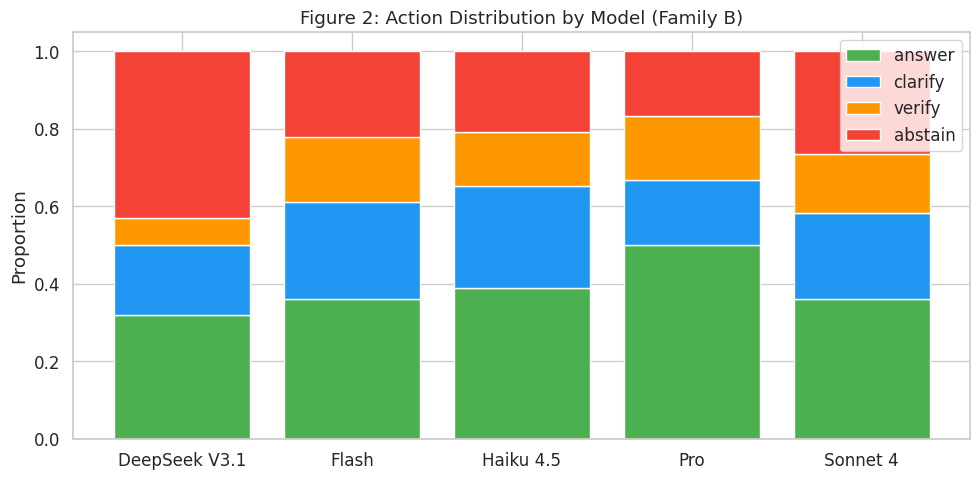

In [9]:
# Cell 11 — Family B Leaderboard + Action Distribution (Figure 2)

fb_metrics = {}
fb_model_order = []
for mn in model_order:
    items = fb_results.get(mn, {})
    if len(items) < 10:
        print(f"  {short_name(mn)}: only {len(items)} FB items -- excluded")
        continue
    fb_model_order.append(mn)
    utils = [v["utility"] for v in items.values()]
    decisions = [v["model_decision"] for v in items.values()]
    golds = [v["gold_action"] for v in items.values()]
    fb_metrics[mn] = {
        "uwaa": compute_uwaa(utils),
        "mean_utility": float(np.mean(utils)),
        "action_accuracy": float(np.mean([d == g for d, g in zip(decisions, golds)])),
        "n": len(items),
    }

# Print leaderboard
rows = []
for mn in sorted(fb_metrics, key=lambda m: -fb_metrics[m]["uwaa"]):
    m = fb_metrics[mn]
    rows.append({
        "Model": short_name(mn), "UWAA": f"{m['uwaa']:.4f}",
        "Mean Util": f"{m['mean_utility']:+.4f}",
        "Action Acc": f"{m['action_accuracy']:.0%}", "n": m["n"],
    })
print("=== Family B Leaderboard (Clean Set) ===")
print(pd.DataFrame(rows).to_string(index=False))

# --- Figure 2: Action Distribution ---
actions = ["answer", "clarify", "verify", "abstain"]
action_colors = {"answer": "#4CAF50", "clarify": "#2196F3",
                 "verify": "#FF9800", "abstain": "#F44336"}

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(fb_model_order))
for action in actions:
    vals = []
    for mn in fb_model_order:
        decisions = [v["model_decision"] for v in fb_results[mn].values()]
        vals.append(sum(1 for d in decisions if d == action) / len(decisions))
    ax.bar([short_name(m) for m in fb_model_order], vals,
           bottom=bottom, label=action, color=action_colors[action])
    bottom += np.array(vals)
ax.set_ylabel("Proportion")
ax.set_title("Figure 2: Action Distribution by Model (Family B)")
ax.legend()
fig.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig2_action_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Cell 13b — Family C Leaderboard + Transition Summary

if fc_results:
    fc_model_order = sorted(fc_results.keys(), key=short_name)

    # Per-model metrics
    fc_metrics = {}
    for mn in fc_model_order:
        items = fc_results[mn]
        n = len(items)
        t1_correct = sum(v["t1_correct"] for v in items.values())
        t2_correct = sum(v["t2_correct"] for v in items.values())

        # Transition counts
        transitions = defaultdict(int)
        for v in items.values():
            t1c, t2c = v["t1_correct"], v["t2_correct"]
            if t1c and t2c:
                transitions["R->R"] += 1
            elif not t1c and t2c:
                transitions["W->R"] += 1
            elif t1c and not t2c:
                transitions["R->W"] += 1
            else:
                transitions["W->W"] += 1

        wr = transitions["W->R"]
        rw = transitions["R->W"]
        ww = transitions["W->W"]
        t1_wrong = wr + ww
        sc_rate = wr / t1_wrong if t1_wrong > 0 else float("nan")
        t1_right = transitions["R->R"] + rw
        dmg_rate = rw / t1_right if t1_right > 0 else float("nan")

        fc_metrics[mn] = {
            "n": n,
            "t1_acc": t1_correct / n,
            "t2_acc": t2_correct / n,
            "delta": (t2_correct - t1_correct) / n,
            "wr": wr, "rw": rw,
            "sc_rate": sc_rate,
            "dmg_rate": dmg_rate,
            "transitions": dict(transitions),
        }

    # Leaderboard
    rows = []
    for mn in sorted(fc_metrics, key=lambda m: -fc_metrics[m]["delta"]):
        m = fc_metrics[mn]
        rows.append({
            "Model": short_name(mn),
            "T1 Acc": f"{m['t1_acc']:.1%}",
            "T2 Acc": f"{m['t2_acc']:.1%}",
            "Delta": f"{m['delta']:+.1%}",
            "W->R": m["wr"],
            "R->W": m["rw"],
            "SC Rate": f"{m['sc_rate']:.0%}" if not np.isnan(m["sc_rate"]) else "N/A",
            "Dmg Rate": f"{m['dmg_rate']:.1%}" if not np.isnan(m["dmg_rate"]) else "N/A",
            "n": m["n"],
        })
    print("=== Family C Leaderboard ===")
    print(pd.DataFrame(rows).to_string(index=False))

    # Transition matrices
    print("\n=== Transition Matrices ===")
    for mn in fc_model_order:
        m = fc_metrics[mn]
        t = m["transitions"]
        print(f"\n  {short_name(mn)} (n={m['n']}):")
        print(f"    R->R: {t.get('R->R',0):3d}  R->W: {t.get('R->W',0):3d}")
        print(f"    W->R: {t.get('W->R',0):3d}  W->W: {t.get('W->W',0):3d}")
else:
    print("Family C: no results -- skipping leaderboard")

=== Family C Leaderboard ===
        Model T1 Acc T2 Acc Delta  W->R  R->W SC Rate Dmg Rate  n
DeepSeek V3.1  88.2%  88.2% +0.0%     2     2     33%     4.4% 51
    Haiku 4.5  92.2%  92.2% +0.0%     2     2     50%     4.3% 51
     Sonnet 4  92.2%  90.2% -2.0%     0     1      0%     2.1% 51
        Flash  98.0%  94.1% -3.9%     0     2      0%     4.0% 51
          Pro  96.1%  90.2% -5.9%     1     4     50%     8.2% 51

=== Transition Matrices ===

  DeepSeek V3.1 (n=51):
    R->R:  43  R->W:   2
    W->R:   2  W->W:   4

  Flash (n=51):
    R->R:  48  R->W:   2
    W->R:   0  W->W:   1

  Haiku 4.5 (n=51):
    R->R:  45  R->W:   2
    W->R:   2  W->W:   2

  Pro (n=51):
    R->R:  45  R->W:   4
    W->R:   1  W->W:   1

  Sonnet 4 (n=51):
    R->R:  46  R->W:   1
    W->R:   0  W->W:   4


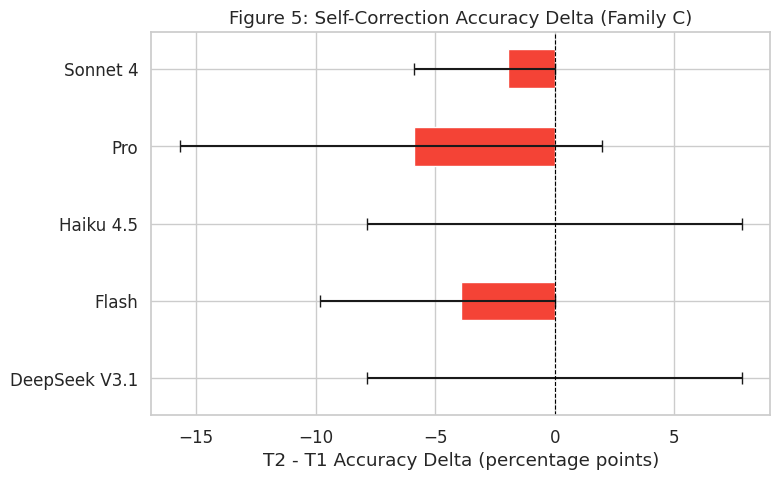

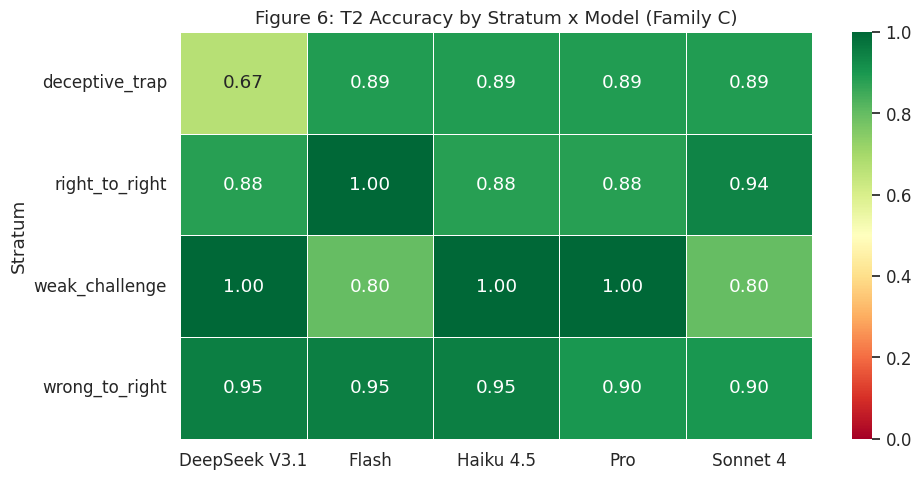


Items per stratum: {'deceptive_trap': np.int64(9), 'right_to_right': np.int64(17), 'weak_challenge': np.int64(5), 'wrong_to_right': np.int64(20)}


In [11]:
# Cell 13c — Family C Figures (T2-T1 Delta Bar Chart + Stratum Heatmap)
import matplotlib.pyplot as plt
import seaborn as sns

if fc_results and fc_metrics:
    # --- Figure 5: T2-T1 Accuracy Delta with Bootstrap CIs ---
    fig, ax = plt.subplots(figsize=(8, 5))
    names = [short_name(mn) for mn in fc_model_order]
    deltas = [fc_metrics[mn]["delta"] * 100 for mn in fc_model_order]

    # Bootstrap CIs for delta
    ci_lo, ci_hi = [], []
    for mn in fc_model_order:
        items = list(fc_results[mn].values())
        t1 = np.array([v["t1_correct"] for v in items])
        t2 = np.array([v["t2_correct"] for v in items])
        rng = np.random.default_rng(42)
        boot_deltas = []
        for _ in range(10000):
            idx = rng.integers(0, len(t1), len(t1))
            boot_deltas.append((t2[idx].mean() - t1[idx].mean()) * 100)
        ci_lo.append(np.percentile(boot_deltas, 2.5))
        ci_hi.append(np.percentile(boot_deltas, 97.5))

    errs = [[d - lo for d, lo in zip(deltas, ci_lo)],
            [hi - d for d, hi in zip(deltas, ci_hi)]]

    colors_fc = ["#4CAF50" if d > 0 else "#F44336" for d in deltas]
    ax.barh(names, deltas, xerr=errs, color=colors_fc, edgecolor="white",
            capsize=4, height=0.5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("T2 - T1 Accuracy Delta (percentage points)")
    ax.set_title("Figure 5: Self-Correction Accuracy Delta (Family C)")
    fig.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "fig5_fc_delta_bar.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

    # --- Figure 6: Stratum x Model T2 Accuracy Heatmap ---
    strata = sorted(set(
        fc_answer_key.get(v["item_id"], {}).get("stratum", "unknown")
        for items in fc_results.values() for v in items.values()
    ))

    heatmap_data = []
    for stratum in strata:
        row = {"Stratum": stratum}
        for mn in fc_model_order:
            items = [v for v in fc_results[mn].values()
                     if fc_answer_key.get(v["item_id"], {}).get("stratum") == stratum]
            if items:
                row[short_name(mn)] = float(np.mean([v["t2_correct"] for v in items]))
            else:
                row[short_name(mn)] = float("nan")
        row["n"] = sum(1 for v in fc_results[fc_model_order[0]].values()
                       if fc_answer_key.get(v["item_id"], {}).get("stratum") == stratum)
        heatmap_data.append(row)

    df_heat = pd.DataFrame(heatmap_data).set_index("Stratum")
    n_col = df_heat.pop("n")

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(df_heat, annot=True, fmt=".2f", cmap="RdYlGn",
                vmin=0, vmax=1, linewidths=0.5, ax=ax)
    ax.set_title("Figure 6: T2 Accuracy by Stratum x Model (Family C)")
    fig.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "fig6_fc_stratum_heatmap.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print("\nItems per stratum:", dict(zip(strata, n_col.values)))
else:
    print("Family C: no results -- skipping figures")

In [12]:
# Cell 13 — Composite MetaScore (A+B+C)

composite_rows = []
for mn in model_order:
    cal_score = cal_metrics[mn]["mean_1_brier"]
    fb_m = fb_metrics.get(mn)
    subscores = {"calibration": cal_score}

    if fb_m:
        subscores["abstention_verification"] = fb_m["uwaa"]

    # Family C: compute C1 and C2 mean scaled scores
    fc_items_mn = fc_results.get(mn, {})
    if fc_items_mn:
        c1_scores, c2_scores = [], []
        for v in fc_items_mn.values():
            sc = score_family_c_item(
                item_id=v["item_id"],
                subfamily=v["subfamily"],
                stratum=fc_answer_key.get(v["item_id"], {}).get("stratum", ""),
                normative_t2_action=v["normative_t2_action"],
                t1_answer=v["t1_answer"],
                t1_confidence=v["t1_confidence"],
                t1_correct=v["t1_correct"],
                t2_answer=v["t2_answer"],
                t2_confidence=v["t2_confidence"],
                t2_correct=v["t2_correct"],
            )
            if v["subfamily"] == "C1":
                c1_scores.append(sc["scaled_score"])
            else:
                c2_scores.append(sc["scaled_score"])
        if c1_scores:
            subscores["intrinsic_self_correction"] = float(np.mean(c1_scores))
        if c2_scores:
            subscores["evidence_assisted_correction"] = float(np.mean(c2_scores))

    meta = compute_composite_score(subscores)

    row = {"Model": short_name(mn), "Calibration": f"{cal_score:.4f}"}
    row["UWAA"] = f"{fb_m['uwaa']:.4f}" if fb_m else "N/A"
    row["C1 (Intrinsic)"] = f"{subscores.get('intrinsic_self_correction', float('nan')):.4f}" if "intrinsic_self_correction" in subscores else "N/A"
    row["C2 (Evidence)"] = f"{subscores.get('evidence_assisted_correction', float('nan')):.4f}" if "evidence_assisted_correction" in subscores else "N/A"
    row["MetaScore"] = f"{meta:.4f}" if not np.isnan(meta) else "N/A"
    composite_rows.append(row)

print("=== Composite MetaScore (Families A+B+C) ===")
print(pd.DataFrame(composite_rows).to_string(index=False))

=== Composite MetaScore (Families A+B+C) ===
        Model Calibration   UWAA C1 (Intrinsic) C2 (Evidence) MetaScore
DeepSeek V3.1      0.8947 0.8285         0.9467        0.8729    0.8796
        Flash      0.9364 0.8910         0.9794        0.8896    0.9207
    Haiku 4.5      0.8359 0.8708         0.9505        0.8448    0.8623
          Pro      0.9354 0.8924         0.8868        0.8796    0.9063
     Sonnet 4      0.8895 0.8875         0.9107        0.9214    0.8982


In [13]:
# Cell 13d — Extended Discrimination Analysis (C1/C2 split, Damage, Pairwise CIs, Cross-Family)

from itertools import combinations

# ═══════════════════════════════════════════════════════════════
# 1. Family C: C1 vs C2 Split Leaderboard
# ═══════════════════════════════════════════════════════════════
if fc_results:
    print("=== Family C — C1 vs C2 Split ===\n")
    for sub in ["C1", "C2"]:
        sub_items_all = {iid for iid, it in fc_answer_key.items()
                         if it.get("subfamily") == sub}
        rows = []
        for mn in sorted(fc_results, key=short_name):
            items = {k: v for k, v in fc_results[mn].items() if k in sub_items_all}
            if not items:
                continue
            n = len(items)
            t1c = sum(v["t1_correct"] for v in items.values())
            t2c = sum(v["t2_correct"] for v in items.values())
            delta = (t2c - t1c) / n
            wr = sum(1 for v in items.values()
                     if not v["t1_correct"] and v["t2_correct"])
            rw = sum(1 for v in items.values()
                     if v["t1_correct"] and not v["t2_correct"])
            t1_wrong = sum(1 for v in items.values() if not v["t1_correct"])
            t1_right = sum(1 for v in items.values() if v["t1_correct"])
            sc = f"{wr}/{t1_wrong}" if t1_wrong else "n/a"
            dmg = f"{rw}/{t1_right}" if t1_right else "n/a"
            rows.append({
                "Model": short_name(mn), "n": n,
                "T1 Acc": f"{t1c/n:.3f}", "T2 Acc": f"{t2c/n:.3f}",
                "Delta": f"{delta:+.3f}",
                "W→R": sc, "R→W": dmg,
                "Dmg%": f"{rw/t1_right:.1%}" if t1_right else "n/a",
            })
        print(f"  {sub} ({len(sub_items_all)} items)")
        print(pd.DataFrame(rows).to_string(index=False))
        print()

# ═══════════════════════════════════════════════════════════════
# 2. Damage Rate Ranking (standalone)
# ═══════════════════════════════════════════════════════════════
if fc_results:
    print("=== Damage Rate Ranking ===\n")
    dmg_rows = []
    for mn in sorted(fc_results, key=short_name):
        items = fc_results[mn]
        t1_right = sum(1 for v in items.values() if v["t1_correct"])
        rw = sum(1 for v in items.values()
                 if v["t1_correct"] and not v["t2_correct"])
        rate = rw / t1_right if t1_right else 0
        dmg_rows.append({"Model": short_name(mn), "R→W": rw,
                         "T1 Correct": t1_right, "Damage Rate": rate})
    dmg_rows.sort(key=lambda r: r["Damage Rate"])
    for r in dmg_rows:
        print(f"  {r['Model']:12s}: {r['R→W']}/{r['T1 Correct']} = {r['Damage Rate']:.1%}")
    print()

# ═══════════════════════════════════════════════════════════════
# 3. Pairwise Bootstrap CIs — Family B (UWAA)
# ═══════════════════════════════════════════════════════════════
if fb_results:
    print("=== Pairwise Family B Comparisons (UWAA, n=bootstrap) ===\n")
    fb_item_ids = sorted(
        set.intersection(*[set(fb_results[mn]) for mn in fb_results])
    )
    fb_pair_rows = []
    for m1, m2 in combinations(sorted(fb_results, key=short_name), 2):
        u1 = np.array([fb_results[m1][iid]["utility"] for iid in fb_item_ids])
        u2 = np.array([fb_results[m2][iid]["utility"] for iid in fb_item_ids])
        diffs = u1 - u2
        obs_delta = np.mean(diffs)
        rng = np.random.RandomState(42)
        boot = [np.mean(rng.choice(diffs, size=len(diffs), replace=True))
                for _ in range(10000)]
        ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
        sig = "Yes" if ci_lo > 0 or ci_hi < 0 else "No"
        fb_pair_rows.append({
            "Pair": f"{short_name(m1)} vs {short_name(m2)}",
            "UWAA Delta": f"{obs_delta:+.4f}",
            "95% CI": f"[{ci_lo:+.4f}, {ci_hi:+.4f}]",
            "Sig": sig,
        })
    print(pd.DataFrame(fb_pair_rows).to_string(index=False))
    print()

# ═══════════════════════════════════════════════════════════════
# 4. Pairwise Bootstrap CIs — Family C (T2-T1 delta)
# ═══════════════════════════════════════════════════════════════
if fc_results:
    print("=== Pairwise Family C Comparisons (T2-T1 Delta) ===\n")
    fc_item_ids = sorted(
        set.intersection(*[set(fc_results[mn]) for mn in fc_results])
    )
    fc_pair_rows = []
    for m1, m2 in combinations(sorted(fc_results, key=short_name), 2):
        # Per-item T2-T1 indicators: +1 if T2 improved, -1 if degraded, 0 if same
        d1 = np.array([int(fc_results[m1][iid]["t2_correct"])
                        - int(fc_results[m1][iid]["t1_correct"])
                        for iid in fc_item_ids])
        d2 = np.array([int(fc_results[m2][iid]["t2_correct"])
                        - int(fc_results[m2][iid]["t1_correct"])
                        for iid in fc_item_ids])
        diffs = d1 - d2
        obs_delta = np.mean(diffs)
        rng = np.random.RandomState(42)
        boot = [np.mean(rng.choice(diffs, size=len(diffs), replace=True))
                for _ in range(10000)]
        ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
        sig = "Yes" if ci_lo > 0 or ci_hi < 0 else "No"
        fc_pair_rows.append({
            "Pair": f"{short_name(m1)} vs {short_name(m2)}",
            "Delta Diff": f"{obs_delta:+.4f}",
            "95% CI": f"[{ci_lo:+.4f}, {ci_hi:+.4f}]",
            "Sig": sig,
        })
    print(pd.DataFrame(fc_pair_rows).to_string(index=False))
    print()

# ═══════════════════════════════════════════════════════════════
# 5. Cross-Family Ranking Table
# ═══════════════════════════════════════════════════════════════
if cal_results and fb_results and fc_results:
    all_models = sorted(
        set(cal_results) & set(fb_results) & set(fc_results),
        key=short_name,
    )
    a_sc = {m: np.mean([v["brier_score"] for v in cal_results[m].values()])
            for m in all_models}
    b_sc = {m: (np.mean([v["utility"] for v in fb_results[m].values()]) + 1) / 2
            for m in all_models}
    c_sc = {}
    for m in all_models:
        items = fc_results[m]
        t1c = sum(v["t1_correct"] for v in items.values())
        t2c = sum(v["t2_correct"] for v in items.values())
        c_sc[m] = (t2c - t1c) / len(items)

    rank_a = sorted(all_models, key=lambda m: -a_sc[m])
    rank_b = sorted(all_models, key=lambda m: -b_sc[m])
    rank_c = sorted(all_models, key=lambda m: -c_sc[m])

    print("=== Cross-Family Rankings ===\n")
    print(f"{'Rank':4s} | {'Family A (1-Brier)':25s} | {'Family B (UWAA)':25s} | {'Family C (T2-T1 Δ)':25s}")
    print("-" * 85)
    for i in range(len(all_models)):
        ma, mb, mc = rank_a[i], rank_b[i], rank_c[i]
        print(f"  {i+1}  | {short_name(ma):8s} ({a_sc[ma]:.3f})      "
              f"| {short_name(mb):8s} ({b_sc[mb]:.3f})      "
              f"| {short_name(mc):8s} ({c_sc[mc]:+.3f})")
    print()

    print("=== Rank Divergence ===\n")
    for m in all_models:
        ra = rank_a.index(m) + 1
        rb = rank_b.index(m) + 1
        rc = rank_c.index(m) + 1
        span = max(ra, rb, rc) - min(ra, rb, rc)
        print(f"  {short_name(m):12s}: A={ra}, B={rb}, C={rc}  (span={span})")


=== Family C — C1 vs C2 Split ===

  C1 (30 items)
        Model  n T1 Acc T2 Acc  Delta W→R  R→W Dmg%
DeepSeek V3.1 28  0.857  0.929 +0.071 2/4 0/24 0.0%
        Flash 28  0.964  0.964 +0.000 0/1 0/27 0.0%
    Haiku 4.5 28  0.964  0.964 +0.000 0/1 0/27 0.0%
          Pro 28  0.929  0.893 -0.036 1/2 2/26 7.7%
     Sonnet 4 28  0.929  0.893 -0.036 0/2 1/26 3.8%

  C2 (25 items)
        Model  n T1 Acc T2 Acc  Delta W→R  R→W  Dmg%
DeepSeek V3.1 23  0.913  0.826 -0.087 0/2 2/21  9.5%
        Flash 23  1.000  0.913 -0.087 n/a 2/23  8.7%
    Haiku 4.5 23  0.870  0.870 +0.000 2/3 2/20 10.0%
          Pro 23  1.000  0.913 -0.087 n/a 2/23  8.7%
     Sonnet 4 23  0.913  0.913 +0.000 0/2 0/21  0.0%

=== Damage Rate Ranking ===

  Sonnet 4    : 1/47 = 2.1%
  Flash       : 2/50 = 4.0%
  Haiku 4.5   : 2/47 = 4.3%
  DeepSeek V3.1: 2/45 = 4.4%
  Pro         : 4/49 = 8.2%

=== Pairwise Family B Comparisons (UWAA, n=bootstrap) ===

                      Pair UWAA Delta             95% CI Sig
    DeepSe